# Data Science Lab on Smart Cities

## Decoding the Intersection between Ridesourcing Dependency and Socio-Demographic Vulnerability in the Chicago FUA

Research question: Is ridesourcing acting as a mobility equalizer or as a costly substitute for inadequate public transport in vulnerable peripheral areas of Chicago?

Analysis:
1. DATA 
2. CONSTRUCT INDICATORS: 
   - TNP Usage Intensity (TUI), 
   - Public Transport Accessibility (PTA), and 
   - Socio-Demographic Vulnerability Index (SDVI) 
3. ...

### 1. Data Sources: 

- CMAP Community Data Snapshots - https://services5.arcgis.com/LcMXE3TFhi1BSaCY/arcgis/rest/services/CommunityDataSnapshots_2015_2025_gdb/FeatureServer
DATA HUB link: https://datahub.cmap.illinois.gov/search?tags=community%2520data%2520snapshots

- Transportation Network Providers - Trips(Chicago Data Portal)
        - 2018 - 2022: https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2018-2022-/m6dm-c72p/data_preview
        - 2023 - 2024: https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2023-2024-/n26f-ihde/data_preview

- Boundaries - Community Areas (Chicago Data Portal)
https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6


### TNP USAGE INTENSITY (TUI)
TNP Usage Intensity measures the number of ridesourcing trips generated in a Community Area during a given time period, normalized by the resident population. Higher values indicate more TNP activity per resident. 
The index should be interpreted as usage intensity rather than dependency unless combined with indicators of public transport accessibility. 

$$TUI= \frac{TNP pickups_{i,m}}{population_{i,m}} *1000$$

where:
- i: community area
- m: month
- TNP pickups: number of ridesourcing trips startint in that community area
- Population: resident population in the community area


In [107]:
# Install dependencies (skipped when already satisfied)
import subprocess
import sys

# PyPI backport shadows stdlib importlib on Python 3.13 and breaks pip
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "importlib"],
    capture_output=True,
)

%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [108]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import utils

importlib.reload(utils)

from utils import (
    build_analysis_gdf,
    build_tui_map,
    compute_tui_correlations,
    load_all_cca_population,
    load_chicago_community_areas,
    load_vulnerability_data,
    plot_tui_index,
    plot_tui_vulnerability_maps,
    plot_tui_vulnerability_scatter,
    save_chart,
    source_tnp_counts,
)


In [109]:
url_2023_2024 = "https://data.cityofchicago.org/resource/n26f-ihde.json"
source_tnp_counts(url_2023_2024, "tnp_counts_2023-2024")

Using cached TNP data: data/tnp_counts_2023-2024.csv


PosixPath('data/tnp_counts_2023-2024.csv')

In [110]:
url_2018_2022 = "https://data.cityofchicago.org/resource/m6dm-c72p.json"
source_tnp_counts(url_2018_2022, "tnp_counts_2018-2022")

Using cached TNP data: data/tnp_counts_2018-2022.csv


PosixPath('data/tnp_counts_2018-2022.csv')

In [111]:
tnp_counts_2018_2022 = pd.read_csv("data/tnp_counts_2018-2022.csv")
tnp_counts_2023_2024 = pd.read_csv("data/tnp_counts_2023-2024.csv")
tnp_counts = pd.concat([tnp_counts_2018_2022, tnp_counts_2023_2024], ignore_index=True)
tnp_counts["month"] = pd.to_datetime(tnp_counts["month"])
tnp_counts["year"] = tnp_counts["month"].dt.year
tnp_counts = tnp_counts.rename(columns={"pickup_community_area": "community_area"})

population = load_all_cca_population("data")
df = pd.merge(tnp_counts, population, on=["community_area", "year"], how="left")

In [112]:
df["tui_index"] = (df["n_trips"] / df["population"]) * 1000

In [113]:
df.to_csv("data/tui_index.csv", index=False)
df.head()

,month,community_area,n_trips,year,community_area_name,population,tui_index
0,2018-11-01,1,99221,2018,Rogers Park,55500.0,1787.765766
1,2018-11-01,2,71955,2018,West Ridge,73723.0,976.018339
2,2018-11-01,3,187550,2018,Uptown,56296.0,3331.497797
3,2018-11-01,4,89958,2018,Lincoln Square,41483.0,2168.550973
4,2018-11-01,5,104623,2018,North Center,34942.0,2994.190373


In [114]:
tui = pd.read_csv("data/tui_index.csv", parse_dates=["month"])
chicago_community_areas = load_chicago_community_areas(
    "data/Boundaries_-_Community_Areas_20260607.geojson"
)

tui_map_2018 = build_tui_map(chicago_community_areas, tui, year=2018)
tui_map_2024 = build_tui_map(chicago_community_areas, tui, year=2024)

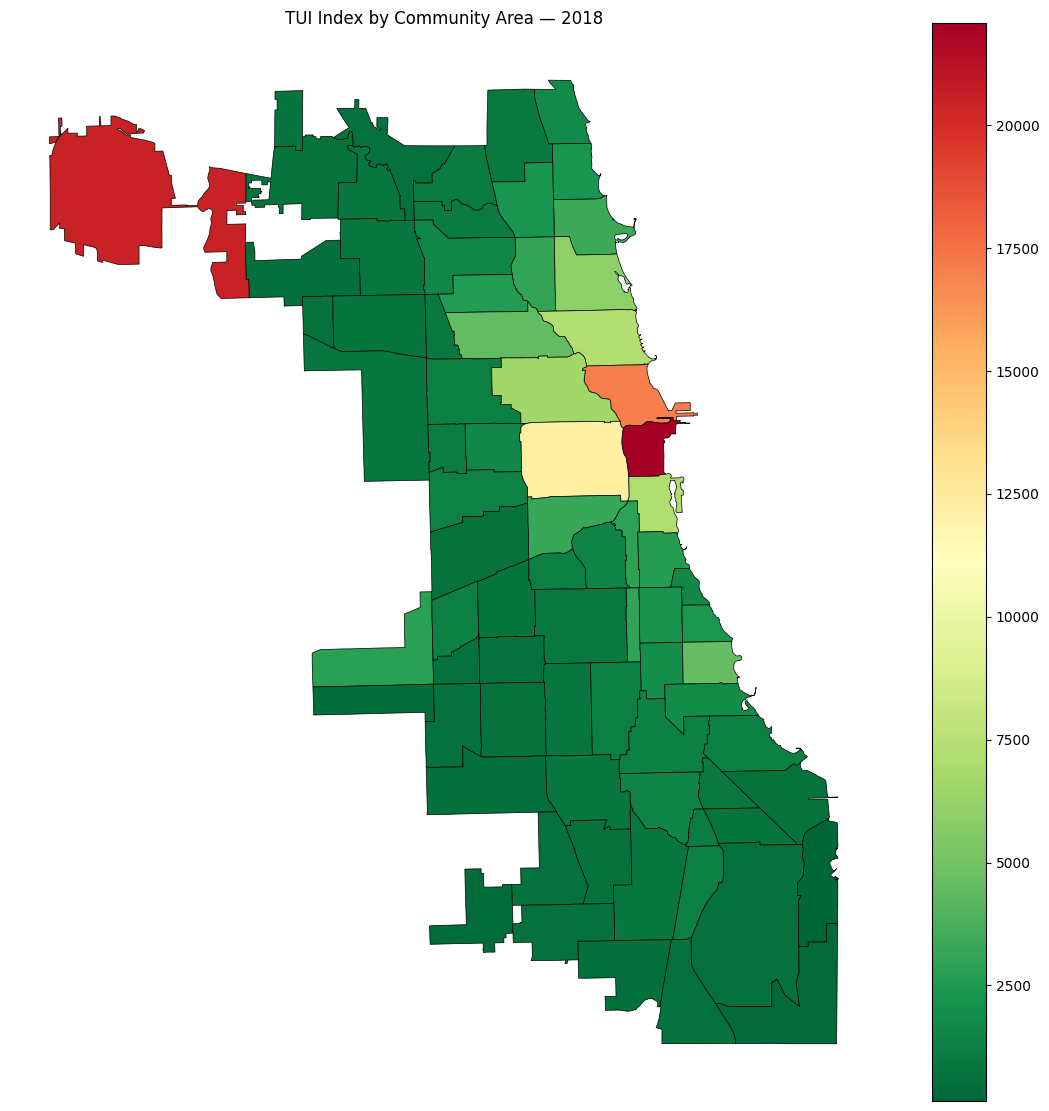

In [115]:
ax = plot_tui_index(tui_map_2018, year=2018, add_labels=False)
save_chart(ax, "tui_2018")
plt.show()

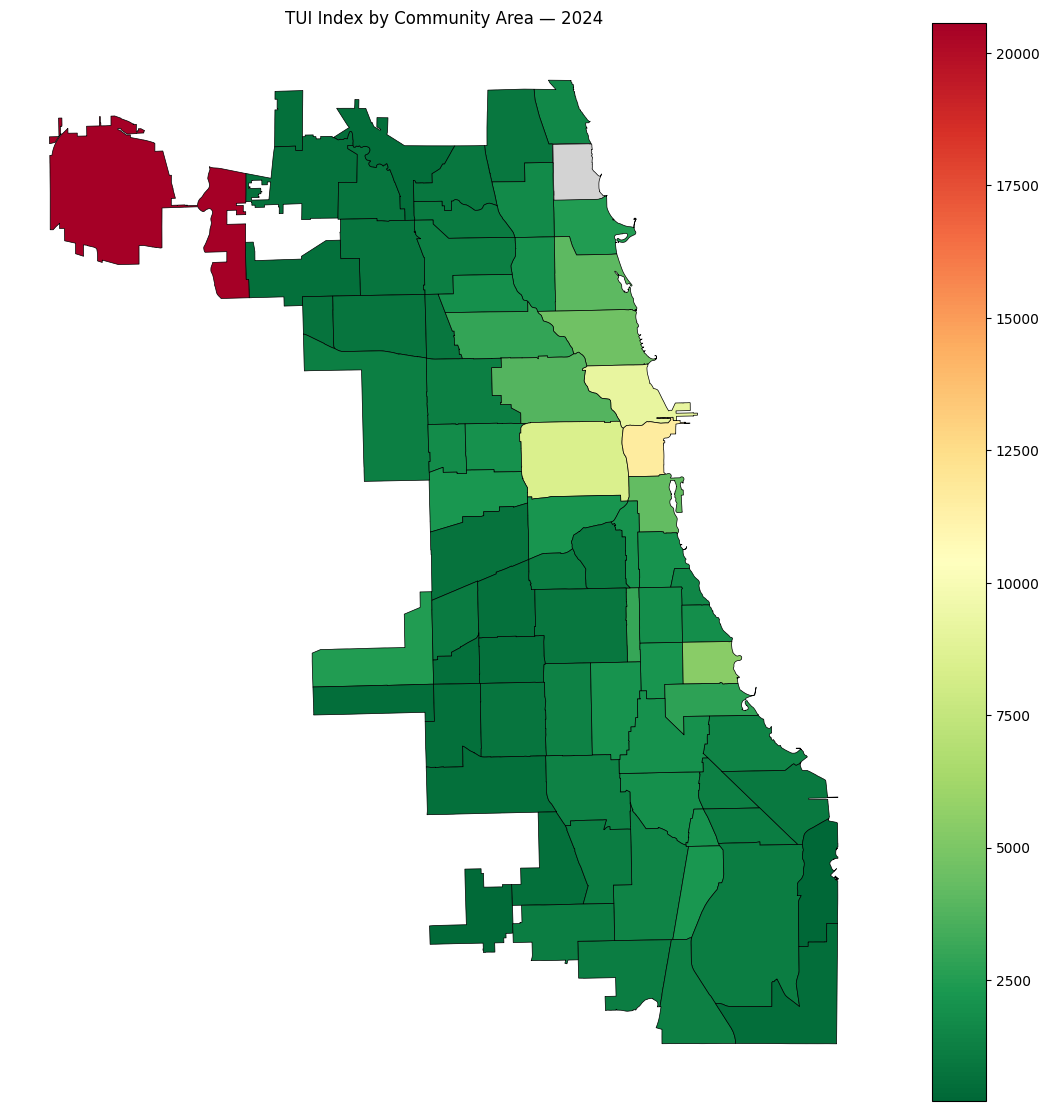

In [116]:
ax = plot_tui_index(tui_map_2024, year=2024, add_labels=False)
save_chart(ax, "tui_2024")
plt.show()

### Socio-Demographic Vulnerability Index (SDVI)

Indice composito che combina il **Hardship Index** e il **reddito per capita** (Chicago Data Portal). Il reddito entra come disadvantage (`-income`): redditi più bassi implicano maggiore vulnerabilità. Valori SDVI più alti indicano maggiore vulnerabilità socio-demografica.

Il **CCVI** resta disponibile come indicatore ausiliario di vulnerabilità sanitaria, ma non entra nel calcolo di SDVI.

**Nota metodologica:** la Community Area 76 (O'Hare) è esclusa dall'analisi perché hub di trasporto outlier.

In [117]:
vulnerability = load_vulnerability_data("data")
analysis_gdf = build_analysis_gdf(tui_map_2024, vulnerability)

print(f"Community Areas in analysis (excl. O'Hare): {len(analysis_gdf)}")
analysis_gdf[[
    "community_area", "community_area_name", "tui_index",
    "hardship_index", "per_capita_income", "hsvi", "sdvi", "ccvi_score",
]].head()

Community Areas in analysis (excl. O'Hare): 75


,community_area,community_area_name,tui_index,hardship_index,per_capita_income,hsvi,sdvi,ccvi_score
0,1,ROGERS PARK,1589.021917,39.0,23939,-0.426475,-0.129999,30.9
1,2,WEST RIDGE,872.629786,46.0,23040,-0.133205,0.021385,36.0
2,3,UPTOWN,2516.201448,20.0,35787,-0.975891,-0.848483,24.4
3,4,LINCOLN SQUARE,1680.655769,17.0,37524,-1.343862,-0.957555,15.0
4,5,NORTH CENTER,1983.218853,6.0,57123,-1.904987,-1.790035,4.0


=== Pearson ===


,tui_index,hsvi,sdvi,ccvi_score
tui_index,1.000,-0.472,-0.542,-0.515
hsvi,-0.472,1.000,0.957,0.950
sdvi,-0.542,0.957,1.000,0.857
ccvi_score,-0.515,0.950,0.857,1.000



=== Spearman ===


,tui_index,hsvi,sdvi,ccvi_score
tui_index,1.000,-0.174,-0.120,-0.255
hsvi,-0.174,1.000,0.960,0.925
sdvi,-0.120,0.960,1.000,0.797
ccvi_score,-0.255,0.925,0.797,1.000


TUI vs HSVI: r=-0.472 (p=0.0000), rho=-0.174 (p=0.1344)
TUI vs SDVI: r=-0.542 (p=0.0000), rho=-0.120 (p=0.3061)
TUI vs CCVI: r=-0.515 (p=0.0000), rho=-0.255 (p=0.0274)


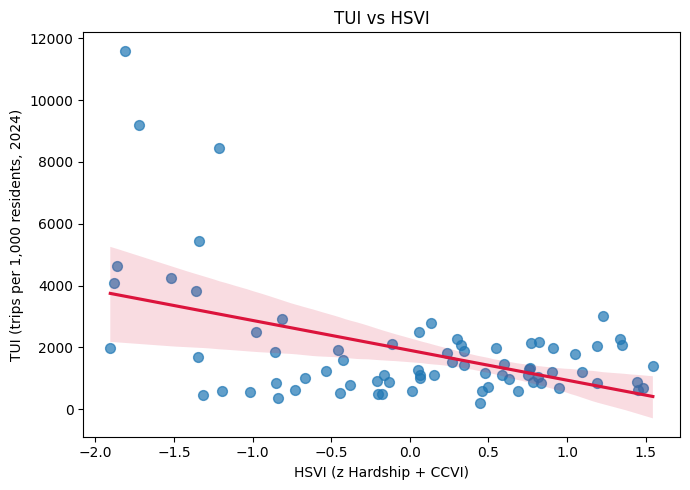

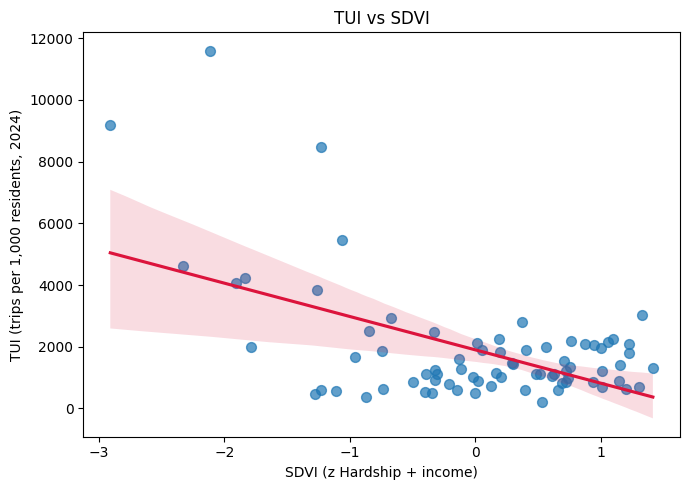

In [118]:
pearson, spearman, tests = compute_tui_correlations(analysis_gdf)

print("=== Pearson ===")
display(pearson.round(3))
print("\n=== Spearman ===")
display(spearman.round(3))

for _, row in tests.iterrows():
    print(
        f"TUI vs {row['indicator']}: "
        f"r={row['pearson_r']:.3f} (p={row['pearson_p']:.4f}), "
        f"rho={row['spearman_rho']:.3f} (p={row['spearman_p']:.4f})"
    )

ax = plot_tui_vulnerability_scatter(analysis_gdf, x="hsvi", year=2024)
save_chart(ax, "tui_vs_hsvi_2024")
plt.tight_layout()
plt.show()

ax = plot_tui_vulnerability_scatter(analysis_gdf, x="sdvi", year=2024)
save_chart(ax, "tui_vs_sdvi_2024")
plt.tight_layout()
plt.show()

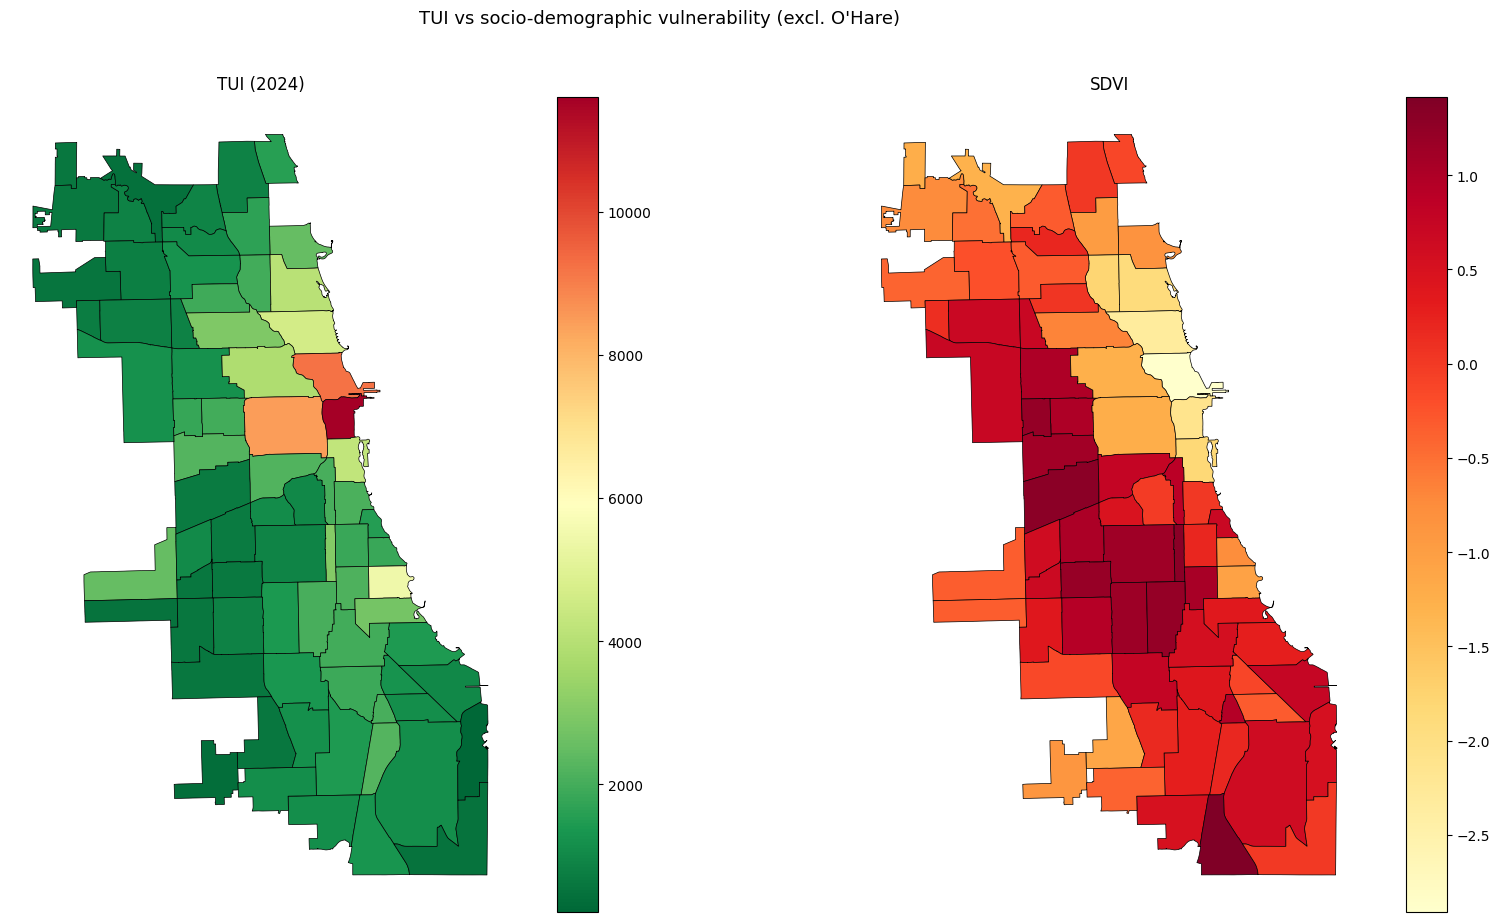

In [ ]:
fig = plot_tui_vulnerability_maps(analysis_gdf, year=2024)
save_chart(fig, "tui_sdvi_maps_2024")
plt.show()

### Weighted TUI (Financial Burden Index)

Stima il carico finanziario del ridesharing per Community Area:

$$\text{total\_spend}_i = \text{n\_trips}_i \times \text{avg\_trip\_cost}$$
$$\text{rideshare\_spend\_pc}_i = \frac{\text{total\_spend}_i}{\text{population}_i}$$
$$\text{Weighted\_TUI}_i = \frac{\text{rideshare\_spend\_pc}_i}{\text{per\_capita\_income}_i}$$

La spesa totale usa il conteggio viaggi annuo moltiplicato per un costo medio per viaggio (proxy, i CSV aggregati non includono il fare). Il denominatore è il reddito pro-capite dal dataframe socio-economico. O'Hare (CA 76) esclusa.

In [ ]:
from utils import (
    DEFAULT_AVG_TRIP_COST_USD,
    build_weighted_tui_map,
    compute_weighted_tui,
    plot_weighted_tui_map,
)

weighted_tui_df = compute_weighted_tui(
    df,
    vulnerability,
    year=2024,
    avg_trip_cost_usd=DEFAULT_AVG_TRIP_COST_USD,
)
weighted_tui_map = build_weighted_tui_map(chicago_community_areas, weighted_tui_df)

print(f"Avg trip cost proxy: ${DEFAULT_AVG_TRIP_COST_USD:.2f}")
display(
    weighted_tui_df[
        ["community_area", "n_trips", "total_spend", "rideshare_spend_pc", "per_capita_income", "Weighted_TUI"]
    ].sort_values("Weighted_TUI", ascending=False).head(10)
)

ax = plot_weighted_tui_map(weighted_tui_map, year=2024)
save_chart(ax, "weighted_tui_2024")
plt.show()

ImportError: cannot import name 'DEFAULT_AVG_TRIP_COST_USD' from 'utils' (/Users/francesca.negri/Documents/SmartCities_Ridesharing/utils.py)